# Linear Regression
The algorithm that learns a formula: from **features** to a **prediction** and how the **training** finds the **parameters $\theta$** that minimize the **error**.

- 0: parameters
- x:features
- ŷ: prediction
- MSE: error

$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3$

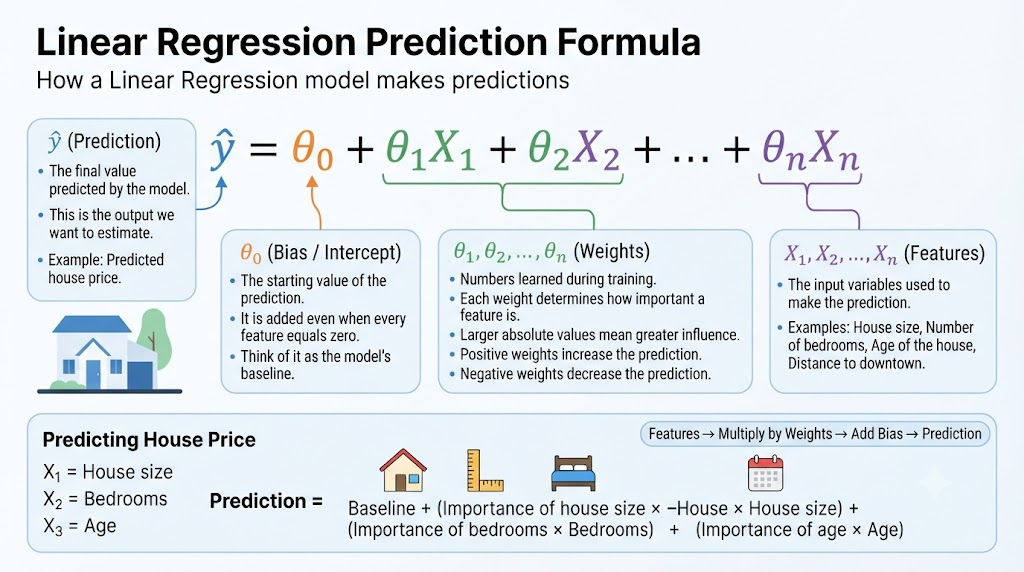

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
plt.rcParams['figure.figsize'] = (9, 5)

## 1. The model is a weighted sum

$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + ... +\theta_n x_n$

Let's assume we **already have** the model parameters (we'll calculate them later):

- $\theta_0 = 50,000$ (bias)
- $\theta_1 = 2,000$ ($ per m²)
- $\theta_2 = 10,000$ ($ per bedroom)

What is the value of a 100m² house with three bedrooms?

In [ ]:
# The weighted sum, by hand
theta_0 = 50_000 # Bias
theta_1 = 2_000 # $ per m²
theta_2 = 10_000 # $ per bedroom

size = 100 
bedrooms = 3

price = (
    theta_0 + 
    theta_1 * size +
    theta_2 * bedrooms
)

price

280000

### The Vectorized Form: The Dot Product

The same calculation can be written as:

$$\hat{y} = \theta * x   $$

The trick is to add **(x_0 = 1)** to the beginning of the feature vector so that the **bias** participates in the same multiplication:

$$\theta_0 * 1 = \theta_0$$

Thus, the vectors become:
- $\theta_0$ = [50000, 2000, 10000]
- $x$ = [1, 100, 3]

In [4]:
theta = np.array([50000, 2000, 10000])
x = np.array([1, 100, 3]) # <- x_0 = 1 always

theta @ x # The doc product: multiply in pairs and add

280000

---

## 2. The dummy dataset: the 3 houses

The same training set as in the theory (small on purpose, so we can **see** each number)

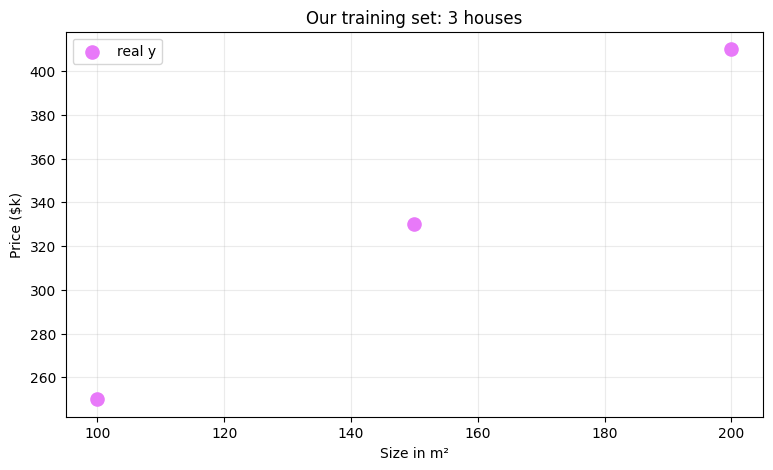

In [5]:
# Size in m² (just one feature for now)
X = np.array([[100.],
             [150.],
             [200.]])

# real price, in milles 
y = np.array([250., 330., 410.])

plt.scatter(X, y, s=90, color="#E879F9", zorder=3, label="real y")
plt.xlabel("Size in m²")
plt.ylabel("Price ($k)")
plt.title("Our training set: 3 houses")
plt.grid(alpha=.25)
plt.legend()
plt.show()

---

## 3. Hot or Cold Training: Test $\theta$ and Measure the Error

Training = finding the $\theta$ that minimizes the **MSE** (Mean Squared Error):

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

We square the values ​​so that the errors **don't cancel each other out** (and incidentally, larger errors carry more weight).

In [7]:
def predict(theta0, theta1, X):
    return theta0 + theta1 * X.ravel()

def mse(theta0, theta1, X, y):
    errors = predict(theta0, theta1, X) - y
    return np.mean(errors ** 2)

# The sequence of attempts of the theory
attempts = [(10, 2), (40, 1.9), (70, 1.7), (90, 1.6)]

for t0, t1 in attempts:
    print(f"θ₀={t0:>3}, θ₁={t1:<4} → MSE = {mse(t0, t1, X, y):.1f}")

θ₀= 10, θ₁=2    → MSE = 666.7
θ₀= 40, θ₁=1.9  → MSE = 175.0
θ₀= 70, θ₁=1.7  → MSE = 41.7
θ₀= 90, θ₁=1.6  → MSE = 0.0


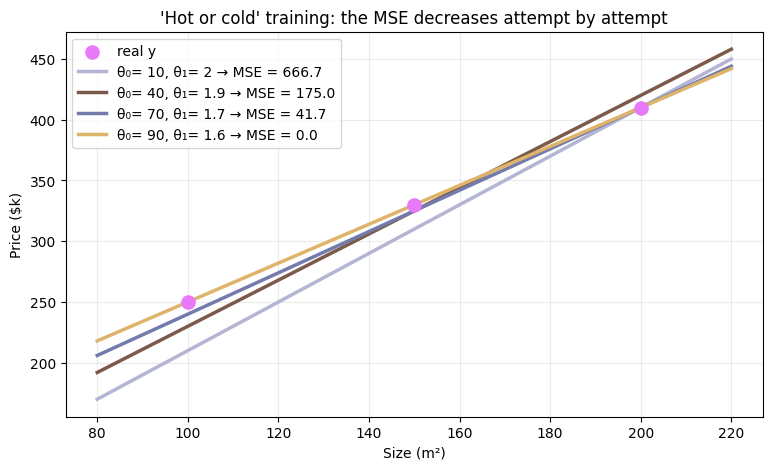

In [8]:
# Let's visualize how each attempt gets closer to the data
colors = ["#b4b4d5", "#7b5a4a", "#737bac", "#deb46a"]
xs = np.array([80, 220])

plt.scatter(X, y, s=90, color="#E879F9", zorder=3, label="real y")
for (t0, t1), color in zip(attempts, colors):
    plt.plot(xs, t0 + t1 * xs, color=color, lw=2.5,
             label=f"θ₀= {t0}, θ₁= {t1} → MSE = {mse(t0, t1, X, y):.1f}")
plt.xlabel("Size (m²)")
plt.ylabel("Price ($k)")
plt.title("'Hot or cold' training: the MSE decreases attempt by attempt")
plt.grid(alpha=.25)
plt.legend()
plt.show()

> The attempt $\theta = (90, 1.6)$ gives **MSE = 0**: the line passes exactly through the 3 points. But we got there by **trial and error.** The million-dollar question: **can they be calculated directly?**

---
## 4. The Normal Equation, step by step
$$
\hat{\theta} = (X^{T}X)^{-1}X^{T}y
$$
Step 0: construct the matrix 'X_b' by adding the **column of 1s** (the usual $x_0 = 1$)

In [9]:
# Cols of 1s for the bias term + the size feature
X_b = np.c_[np.ones((3,1)), X]
print("X_b =\n", X_b)
print("\nshape:", X_b.shape, "→ 3 houses, 2 features (bias + size)")

X_b =
 [[  1. 100.]
 [  1. 150.]
 [  1. 200.]]

shape: (3, 2) → 3 houses, 2 features (bias + size)


In [ ]:
# Step 1 - XtX: row x col (The product of the transposed matrix by the original matrix)
XtX = X_b.T @ X_b
print("XtX =\n", XtX)
print("\nNote: It no longer represents houses. (Summary of the dataset):")
print(" 3 = nums of examples")
print(" 450 = sum of sizes")
print(" 72500 = sum of sizes²")

XtX =
 [[    3.   450.]
 [  450. 72500.]]

Note: It no longer represents houses. (Summary of the dataset):
 3 = nums of examples
 450 = sum of sizes
 72500 = sum of sizes²


In [12]:
# Step 2 - The inverse (doing it by hand is heavy algebra; NumPy does it for us)
XtX_inv = np.linalg.inv(XtX)
XtX_inv

array([[ 4.8333, -0.03  ],
       [-0.03  ,  0.0002]])

In [13]:
# Step 3 - Xty: row x col (The product of the transposed matrix by the target vector)
Xty = X_b.T @ y
print("\nXty =\n", Xty)
print(" 990 = sum of prices")
print("156500 = sum of sizes * prices")


Xty =
 [   990. 156500.]
 990 = sum of prices
156500 = sum of sizes * prices


In [14]:
# Step 4 - The final step: the product of the inverse by the target vector
theta_best = XtX_inv @ Xty

# The same thetha that was hot/cold, groping for it
theta_best

array([90. ,  1.6])

In [18]:
# Verifying the result: Does the straight line hit all 3 houses?
for size, real in zip(X.ravel(), y):
    pred = theta_best[0] + theta_best[1] * size
    print(f"{size:>3} m² → real price: ${real:.0f}k     (predicted price: ${pred:.0f}k)")

100.0 m² → real price: $250k     (predicted price: $250k)
150.0 m² → real price: $330k     (predicted price: $330k)
200.0 m² → real price: $410k     (predicted price: $410k)


---
## 5. Changing Features → Changing Matrices

Let's add **rooms** as the second feature and see how the matrices **grow**:

In [19]:
bedrooms = np.array([[2.], [3.], [3.]])

X2_b = np.c_[np.ones((3, 1)), X, bedrooms]
XtX2 = X2_b.T @ X2_b

print("With one features: X_b", X_b.shape, "→ XtX", XtX.shape)
print("With two features: X2_b", X2_b.shape, "→ XtX2", XtX2.shape)
print("\nXtX now is: \n", XtX2)

With one features: X_b (3, 2) → XtX (2, 2)
With two features: X2_b (3, 3) → XtX2 (3, 3)

XtX now is: 
 [[    3.   450.     8.]
 [  450. 72500.  1250.]
 [    8.  1250.    22.]]


In [20]:
theta_2f = np.linalg.inv(XtX2) @ X2_b.T @ y
print("theta with two features: ", theta_2f)
print("Predictions: ", X2_b @ theta_2f)

theta with two features:  [90.   1.6  0. ]
Predictions:  [250. 330. 410.]


---
## 6. Now then: scikit-learn in 3 lines
Everything above (column of 1s, matrices, inverse) lives within `LinearRegression`:

In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("intercept_ (θ₀):", lin_reg.intercept_)
print("coef_ (θ₁):", lin_reg.coef_)

intercept_ (θ₀): 90.0
coef_ (θ₁): [1.6]


In [22]:
# And predicting is just one more method
new_houses = np.array([[120.], [175.]])
lin_reg.predict(new_houses)

array([282., 370.])

Same $\theta$, zero manual algebra.

> Note: scikit-learn **separates** the bias (`intercept_`) from the weights (`coef_`), and underneath it doesn't use the literal Normal Equation but **SVD/pseudo-inverse** (more stable and O(n**2) instead of O(n**3)).

---
## 7. A more realistic example: 500 houses with noise

We generate a synthetic dataset where we **know the true $\theta$ values** (so we can check if the model recovers them). As in real life, we add **noise**.

In [24]:
rng = np.random.default_rng(seed=42)
m = 500

size = rng.uniform(40, 250, (m, 1)) # m**2
bedroom = rng.integers(1, 6, (m, 1)).astype(float) # bedrooms
year = rng.uniform(0, 50, (m, 1)) # years since built

X_real = np.c_[size, bedroom, year]

# The "nature's theta": 50,000 base, +2,000/m2, +10,000/bedrooms, -500/year
y_real = (50000 + 2000*size + 10000*bedroom - 500*year + rng.normal(0, 15000, (m, 1))).ravel() # add some "noise"

X_real.shape, y_real.shape

((500, 3), (500,))

In [25]:
# Normal Equation manual in the dataset real
X_real_b = np.c_[np.ones((m, 1)), X_real]
theta_real = np.linalg.inv(X_real_b.T @ X_real_b) @ X_real_b.T @ y_real

print("θ₀ true: [50000, 2000, 10000, -500]")
print("θ₀ recovered:", np.round(theta_real, 1))

θ₀ true: [50000, 2000, 10000, -500]
θ₀ recovered: [47136.2  2008.5 10024.3  -478.6]


In [26]:
# Scikit-learn only for confirmation
lr = LinearRegression().fit(X_real, y_real)
print("intercept_ (θ₀):", round(lr.intercept_,1))
print("coef_ (θ₁,θ₂,θ₃):", np.round(lr.coef_, 1))

intercept_ (θ₀): 47136.2
coef_ (θ₁,θ₂,θ₃): [ 2008.5 10024.3  -478.6]


We didn't recover the exact $\theta$ (noise prevents it!), but we got very close. The smaller and noisier the dataset, the more difficult it is. Let's look at it graphically.

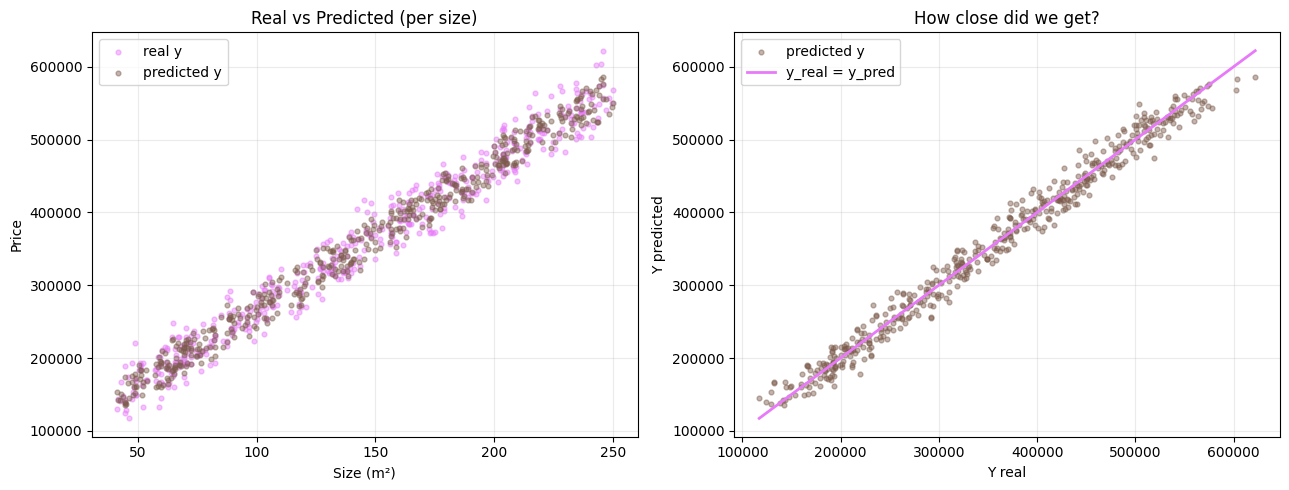

In [29]:
y_pred = lr.predict(X_real)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(size, y_real, s=12, alpha=.45, color="#E879F9", label="real y")
axes[0].scatter(size, y_pred, s=12, alpha=.45, color="#7b5a4a", label="predicted y")
axes[0].set_xlabel("Size (m²)")
axes[0].set_ylabel("Price")
axes[0].set_title("Real vs Predicted (per size)")
axes[0].legend()
axes[0].grid(alpha=.25)

axes[1].scatter(y_real, y_pred, s=12, alpha=.45, color="#7b5a4a", label="predicted y")
lims = [y_real.min(), y_real.max()]

axes[1].plot(lims, lims, color="#E879F9", lw=2, label="y_real = y_pred")
axes[1].set_xlabel("Y real")
axes[1].set_ylabel("Y predicted")
axes[1].set_title("How close did we get?")
axes[1].legend()
axes[1].grid(alpha=.25)

plt.tight_layout()
plt.show()

---
## 8. The hidden cost: complexity O(n**3)
Inverting XtX (an array of `(n+1) * (n+1)`) costs approximately O(n**3): doubling the features multiplies the time by $2³$ = 8.

Let's really measure

In [31]:
import time

def time_normal_equation(n, m=3000):
    """
    Generate a dataset with n features and time the Normal Equation.
    """
    Xn = rng.standard_normal((m, n))
    yn = rng.standard_normal(m)

    Xb = np.c_[np.ones((m, 1)), Xn]
    t0 = time.perf_counter()

    np.linalg.inv(Xb.T @ Xb) @ Xb.T @ yn
    return time.perf_counter() - t0

ns = [50, 100, 200, 400, 800, 1600]
times = {n: time_normal_equation(n) for n in ns}

for n, t in times.items():
    print(f"n = {n:>5} features → {t:.4f}s")

n =    50 features → 0.0383s
n =   100 features → 0.0474s
n =   200 features → 0.0287s
n =   400 features → 0.0263s
n =   800 features → 0.1112s
n =  1600 features → 0.3306s


From **fractions of a second to years** and that's not even considering that the 1,000,000 x 1,000,000 matrix doesn't even fit in memory